# Analyse des scores composites

Analyse des 7 scores composites et de leur relation avec les variables `pct_*` (CSP, diplômes, emploi, mobilité, démographie).

## 1. Imports et configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as spstats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid', font_scale=1.05)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 20)


## 2. Chargement des données et variables dérivées

In [2]:
df = pd.read_csv('iris/iris_final_socio_politique.csv', low_memory=False)
print(f'Shape brut: {df.shape}')

# Population
df['_pop'] = df['pop_totale'].fillna(df['pop_totale'].median()) if 'pop_totale' in df.columns else 2000.0

# Variables dérivées (identiques à rebuild_vizu_iris.py)
_nscol  = df['P21_NSCOL15P'].replace(0, np.nan)
_sal    = df['P21_SAL15P'].replace(0, np.nan)
_actocc = df['P21_ACTOCC15P'].replace(0, np.nan)

df['pct_sup5']              = df['P21_NSCOL15P_SUP5']    / _nscol  * 100
df['pct_sans_diplome']      = df['P21_NSCOL15P_DIPLMIN'] / _nscol  * 100
df['pct_capbep']            = df['P21_NSCOL15P_CAPBEP']  / _nscol  * 100
df['pct_chomage']           = df['P21_CHOM1564']          / df['P21_ACT1564'].replace(0, np.nan) * 100
df['pct_etudiants']         = df['P21_ETUD1564']          / df['P21_POP1564'].replace(0, np.nan) * 100
df['pct_cdi']               = df['P21_SAL15P_CDI']        / _sal    * 100
df['pct_cdd']               = df['P21_SAL15P_CDD']        / _sal    * 100
df['pct_interim']           = df['P21_SAL15P_INTERIM']    / _sal    * 100
df['pct_temps_partiel']     = df['P21_SAL15P_TP']         / _sal    * 100
df['pct_actifs_voiture']    = df['C21_ACTOCC15P_VOIT']   / _actocc * 100
df['pct_actifs_transports'] = df['C21_ACTOCC15P_TCOM']   / _actocc * 100
df['pct_actifs_velo']       = df['C21_ACTOCC15P_VELO']   / _actocc * 100
df['pct_actifs_marche']     = df['C21_ACTOCC15P_MAR']    / _actocc * 100

print('Variables dérivées calculées.')

Shape brut: (49140, 512)
Variables dérivées calculées.


## 3. Calcul des scores composites

In [3]:
def _rang_pondere(series, pop):
    s, p = series.copy().astype(float), pop.copy().astype(float)
    valid = s.notna() & p.notna() & (p > 0)
    if valid.sum() < 10:
        return pd.Series(0.0, index=s.index)
    s_v, p_v = s[valid], p[valid]
    order = s_v.argsort()
    p_sorted = p_v.iloc[order]
    cumsum = p_sorted.cumsum()
    centile = (cumsum - p_sorted / 2) / p_sorted.sum() * 100
    result = pd.Series(np.nan, index=s.index)
    result.iloc[np.where(valid.values)[0][order.values]] = centile.values
    return result.fillna(50.0) - 50.0

def make_score(pos_vars, neg_vars):
    parts = []
    for v in pos_vars:
        if v in df.columns: parts.append(_rang_pondere(df[v], df['_pop']))
    for v in neg_vars:
        if v in df.columns: parts.append(-_rang_pondere(df[v], df['_pop']))
    return pd.concat(parts, axis=1).mean(axis=1) if parts else pd.Series(0.0, index=df.index)

SCORES_CONFIG = {
    'score_exploitation': {
        'pos_vars': ['DISP_PPAT21', 'P21_NSAL15P_EMPLOY', 'pct_csp_plus', 'pct_csp_retraite', 'DISP_MED21', 'DISP_PPEN21', 'DISP_PBEN21'],
        'neg_vars': ['DISP_TP6021', 'DISP_PTSA21', 'P21_NSAL15P_AIDFAM', 'DISP_PPLOGT21'],
    },
    'score_domination': {
        'pos_vars': ['pct_csp_plus', 'pct_csp_intermediaire', 'pct_sup5', 'pct_cdi', 'P21_NSAL15P_EMPLOY'],
        'neg_vars': ['pct_csp_ouvrier', 'pct_csp_sans_emploi', 'pct_csp_employe', 'pct_csp_independant',
                     'pct_sans_diplome', 'pct_capbep', 'pct_cdd', 'pct_interim', 'pct_temps_partiel',
                     'pct_chomage', 'DISP_TP6021', 'DISP_PPSOC21', 'DISP_PPMINI21'],
    },
    'score_cap_cult': {
        'pos_vars': ['pct_csp_plus', 'pct_csp_intermediaire', 'pct_sup5', 'pct_actifs_velo'],
        'neg_vars': ['pct_csp_ouvrier', 'pct_sans_diplome', 'pct_csp_sans_emploi', 'pct_capbep',
                     'pct_interim', 'pct_temps_partiel', 'pct_chomage'],
    },
    'score_cap_eco': {
        'pos_vars': ['DISP_PPAT21', 'P21_NSAL15P_EMPLOY', 'pct_csp_plus', 'pct_csp_retraite', 'DISP_MED21', 'DISP_PPEN21', 'DISP_PBEN21'],
        'neg_vars': ['DISP_TP6021', 'DISP_PTSA21', 'P21_NSAL15P_AIDFAM', 'DISP_PPLOGT21', 'DISP_PCHO21'],
    },
    'score_precarite': {
        'pos_vars': ['DISP_TP6021', 'pct_csp_sans_emploi', 'DISP_PPSOC21', 'DISP_PPMINI21', 'pct_chomage'],
        'neg_vars': ['DISP_MED21', 'DISP_PPAT21'],
    },
    'score_rentier': {
        'pos_vars': ['DISP_PPAT21', 'DISP_PPEN21', 'pct_csp_retraite'],
        'neg_vars': ['DISP_PACT21', 'DISP_PPSOC21', 'pct_csp_employe'],
    },
    'score_ruralite': {
        'pos_vars': ['pct_csp_agriculteur', 'pct_sans_diplome', 'pct_actifs_voiture', 'P21_ACTOCC15P_ILT3'],
        'neg_vars': ['pct_immigres', 'pct_actifs_velo', 'pct_actifs_transports', 'pct_actifs_marche',
                     'pct_etudiants', 'P21_ACTOCC15P_ILT1'],
    },
}

SCORES = list(SCORES_CONFIG.keys())
SCORE_LABELS = [s.replace('score_', '') for s in SCORES]

for name, cfg in SCORES_CONFIG.items():
    df[name] = make_score(cfg['pos_vars'], cfg['neg_vars'])
    print(f'  {name}: min={df[name].min():.1f}  max={df[name].max():.1f}  mean={df[name].mean():.1f}')


  score_exploitation: min=-43.6  max=40.7  mean=1.0
  score_domination: min=-42.3  max=40.9  mean=-2.4
  score_cap_cult: min=-47.9  max=45.3  mean=-4.0
  score_cap_eco: min=-43.8  max=41.0  mean=1.7
  score_precarite: min=-47.5  max=50.0  mean=-2.5
  score_rentier: min=-47.3  max=49.4  mean=4.6
  score_ruralite: min=-39.0  max=42.2  mean=9.4


## 4. Définition des variables `pct_*` et dataset propre

In [4]:
PCT_GROUPS = {
    'CSP':         ['pct_csp_plus', 'pct_csp_intermediaire', 'pct_csp_employe',
                    'pct_csp_ouvrier', 'pct_csp_independant', 'pct_csp_retraite',
                    'pct_csp_sans_emploi', 'pct_csp_agriculteur'],
    'Diplomes':    ['pct_sup5', 'pct_capbep', 'pct_sans_diplome'],
    'Emploi':      ['pct_cdi', 'pct_cdd', 'pct_interim', 'pct_temps_partiel',
                    'pct_chomage', 'pct_etudiants'],
    'Mobilite':    ['pct_actifs_voiture', 'pct_actifs_transports',
                    'pct_actifs_velo', 'pct_actifs_marche'],
    'Demographie': ['pct_0_19', 'pct_20_64', 'pct_65_plus',
                    'pct_immigres', 'pct_etrangers'],
}
PCT_ALL = [v for grp in PCT_GROUPS.values() for v in grp]

# Dataset propre avec reset_index pour éviter les doublons d'index
df_clean = df[SCORES + PCT_ALL].dropna(subset=SCORES).reset_index(drop=True)
df_corr  = df_clean.dropna().reset_index(drop=True)
print(f'IRIS avec scores complets : {len(df_clean)}')
print(f'IRIS avec scores + pct_ complets : {len(df_corr)}')


IRIS avec scores complets : 45650
IRIS avec scores + pct_ complets : 45590


## 5. Statistiques descriptives — scores composites

In [6]:
df_clean[SCORES].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(2)


,mean,std,min,25%,50%,75%,max
score_exploitation,1.04,11.74,-43.59,-5.53,1.68,8.84,40.75
score_domination,-2.43,15.03,-42.26,-13.12,-3.33,7.54,40.92
score_cap_cult,-3.98,16.09,-47.89,-15.67,-5.35,6.75,45.26
score_cap_eco,1.74,12.44,-43.78,-5.33,2.68,10.33,41.01
score_precarite,-2.48,21.34,-47.55,-18.88,-4.59,12.02,49.97
score_rentier,4.62,16.62,-47.32,-6.08,5.87,16.91,49.39
score_ruralite,9.45,15.70,-39.05,0.37,13.63,21.02,42.21


### Distributions

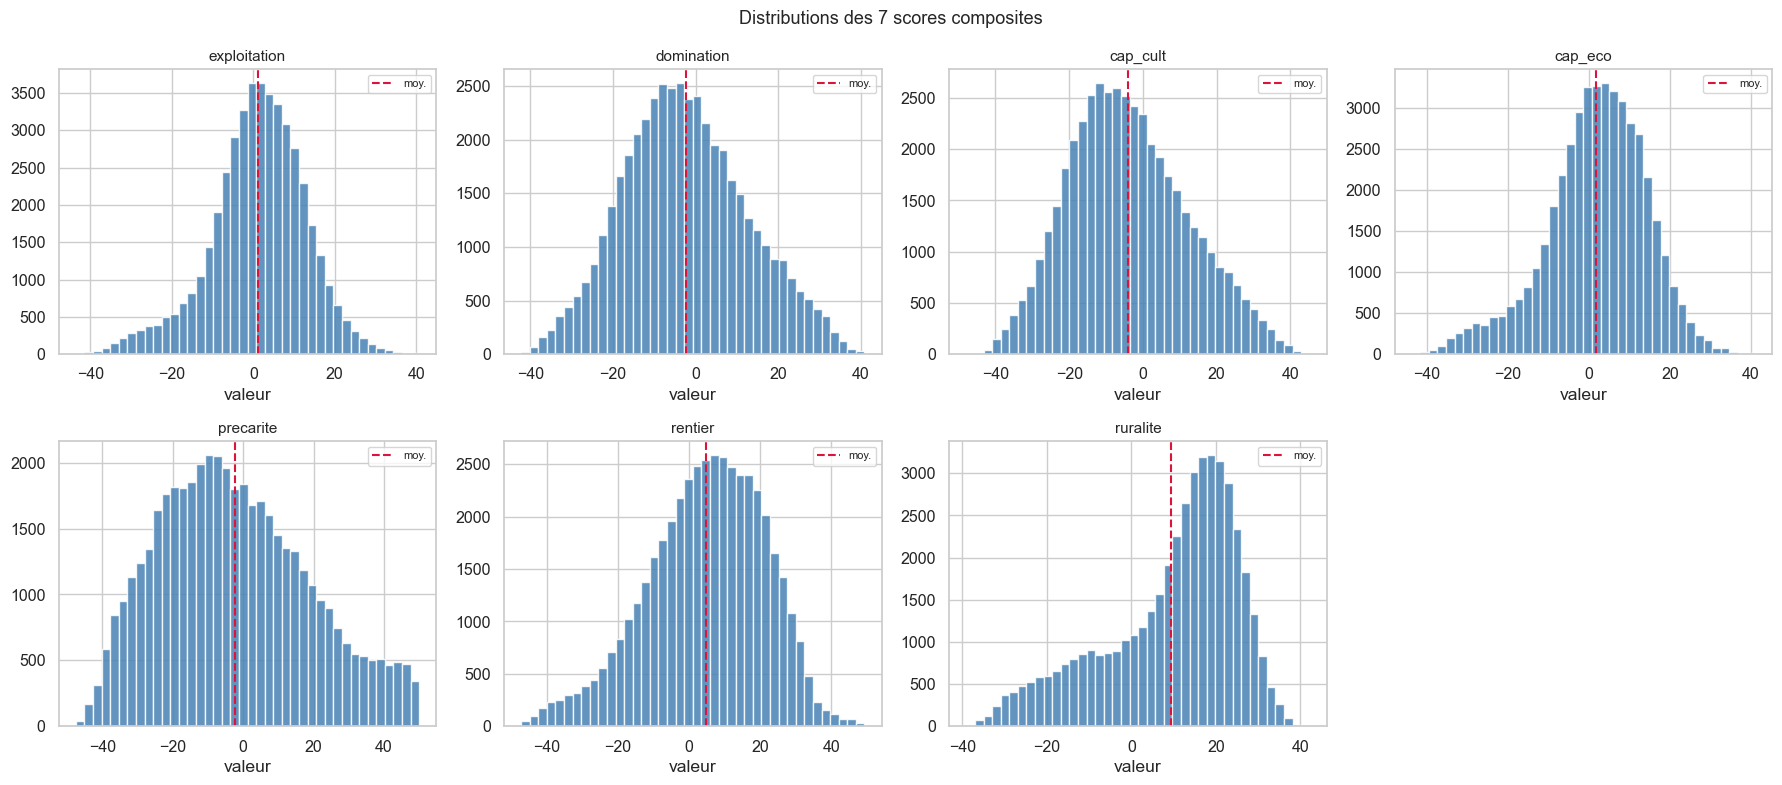

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, s in enumerate(SCORES):
    ax = axes[i]
    ax.hist(df_clean[s].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(df_clean[s].mean(), color='crimson', lw=1.5, ls='--', label='moy.')
    ax.set_title(SCORE_LABELS[i], fontsize=11)
    ax.set_xlabel('valeur')
    ax.legend(fontsize=8)
axes[-1].set_visible(False)
fig.suptitle('Distributions des 7 scores composites', fontsize=13)
plt.tight_layout()
plt.show()


## 6. Corrélations entre scores composites

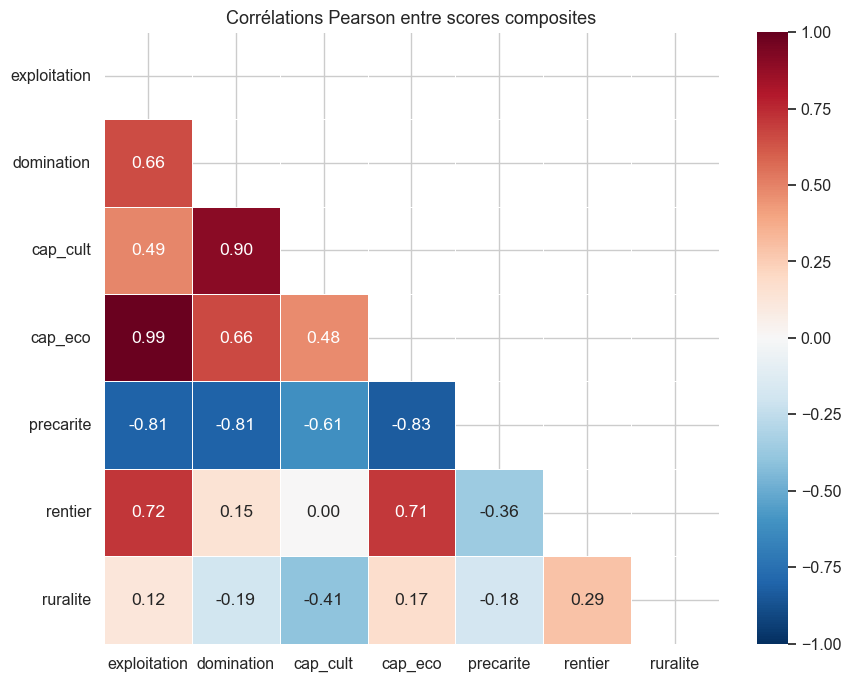

Paires fortement corrélées (|r| > 0.70) :
  exploitation    x cap_eco         -> r = +0.992
  exploitation    x precarite       -> r = -0.806
  exploitation    x rentier         -> r = +0.715
  domination      x cap_cult        -> r = +0.899
  domination      x precarite       -> r = -0.809
  cap_eco         x precarite       -> r = -0.831
  cap_eco         x rentier         -> r = +0.706


In [8]:
corr_scores = df_clean[SCORES].corr()
mask = np.triu(np.ones(corr_scores.shape, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_scores, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', vmin=-1, vmax=1, linewidths=0.5,
            xticklabels=SCORE_LABELS, yticklabels=SCORE_LABELS, ax=ax)
ax.set_title('Corrélations Pearson entre scores composites', fontsize=13)
plt.tight_layout()
plt.show()

print('Paires fortement corrélées (|r| > 0.70) :')
for i in range(len(SCORES)):
    for j in range(i+1, len(SCORES)):
        r = corr_scores.iloc[i, j]
        if abs(r) > 0.70:
            print(f'  {SCORE_LABELS[i]:15s} x {SCORE_LABELS[j]:15s} -> r = {r:+.3f}')


### Scatter plots — paires clés de scores

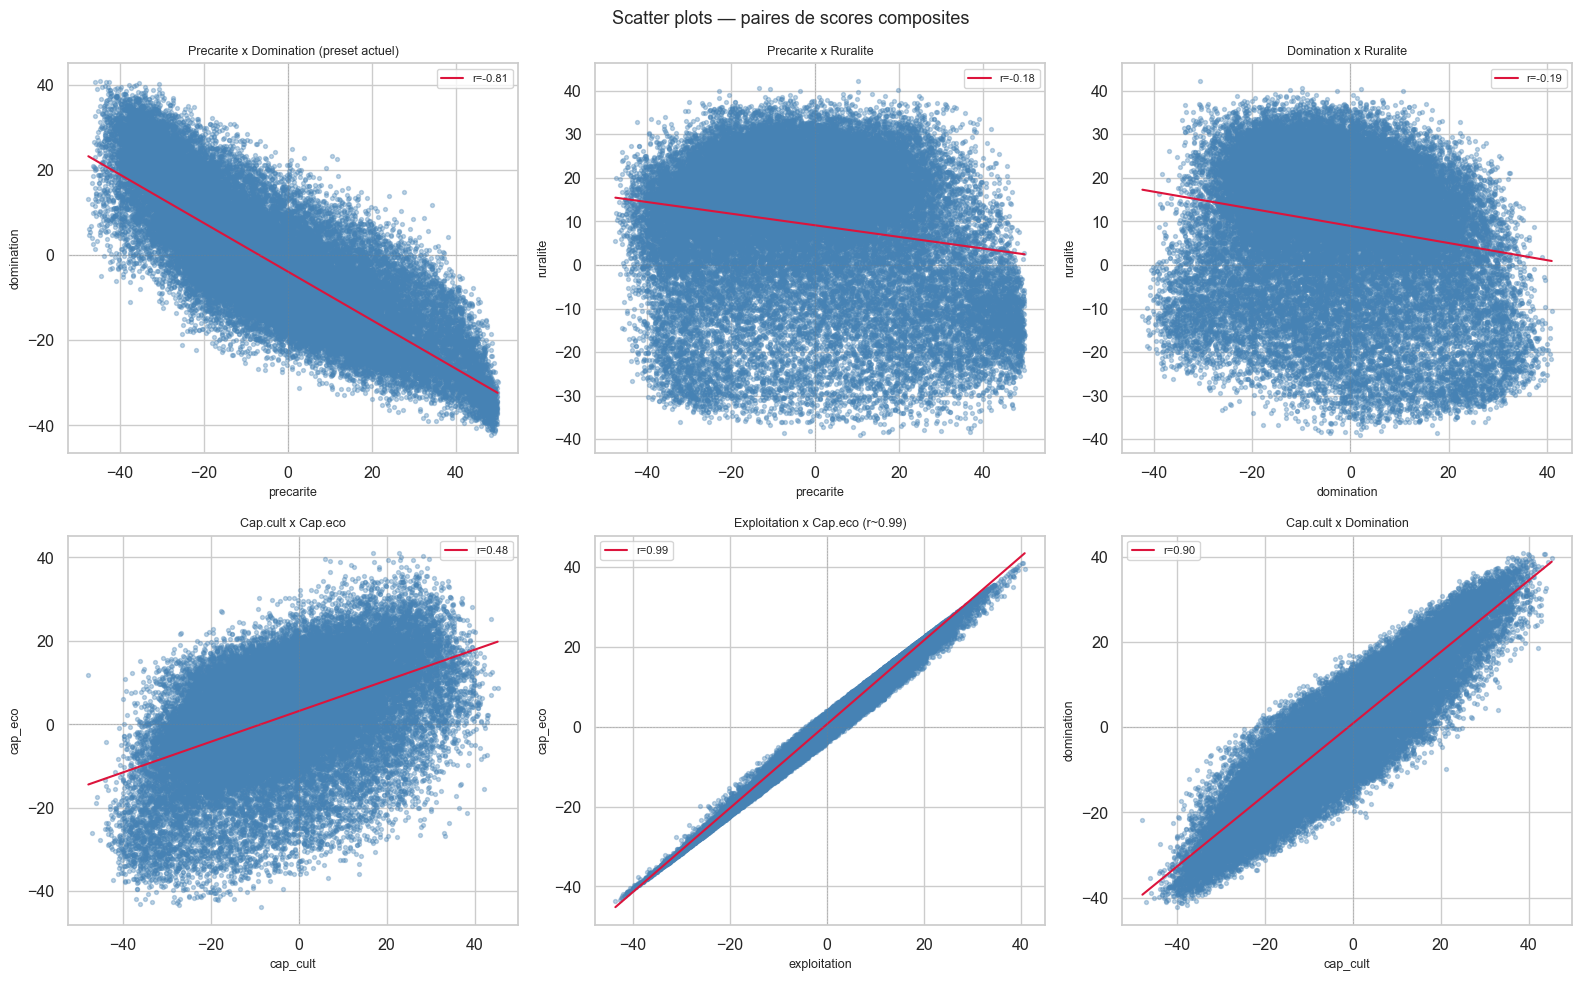

In [9]:
PAIRS_SCORES = [
    ('score_precarite',    'score_domination',  'Precarite x Domination (preset actuel)'),
    ('score_precarite',    'score_ruralite',    'Precarite x Ruralite'),
    ('score_domination',   'score_ruralite',    'Domination x Ruralite'),
    ('score_cap_cult',     'score_cap_eco',     'Cap.cult x Cap.eco'),
    ('score_exploitation', 'score_cap_eco',     'Exploitation x Cap.eco (r~0.99)'),
    ('score_cap_cult',     'score_domination',  'Cap.cult x Domination'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for ax, (x, y, title) in zip(axes, PAIRS_SCORES):
    sub = df_clean[[x, y]].dropna()
    xv, yv = sub[x].values, sub[y].values
    ax.scatter(xv, yv, s=8, alpha=0.35, color='steelblue')
    m, b, r, *_ = spstats.linregress(xv, yv)
    xl = np.linspace(xv.min(), xv.max(), 200)
    ax.plot(xl, m*xl + b, color='crimson', lw=1.5, label=f'r={r:.2f}')
    ax.set_xlabel(x.replace('score_', ''), fontsize=9)
    ax.set_ylabel(y.replace('score_', ''), fontsize=9)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=8)
    ax.axhline(0, color='grey', lw=0.4, ls=':')
    ax.axvline(0, color='grey', lw=0.4, ls=':')
fig.suptitle('Scatter plots — paires de scores composites', fontsize=13)
plt.tight_layout()
plt.show()


## 7. Analyse en composantes principales (PCA)

Variance expliquee par composante :
  PC1: 59.5%  (cumule: 59.5%)
  PC2: 25.2%  (cumule: 84.7%)
  PC3: 10.3%  (cumule: 95.0%)
  PC4: 2.9%  (cumule: 97.9%)
  PC5: 1.3%  (cumule: 99.2%)
  PC6: 0.7%  (cumule: 99.9%)
  PC7: 0.1%  (cumule: 100.0%)


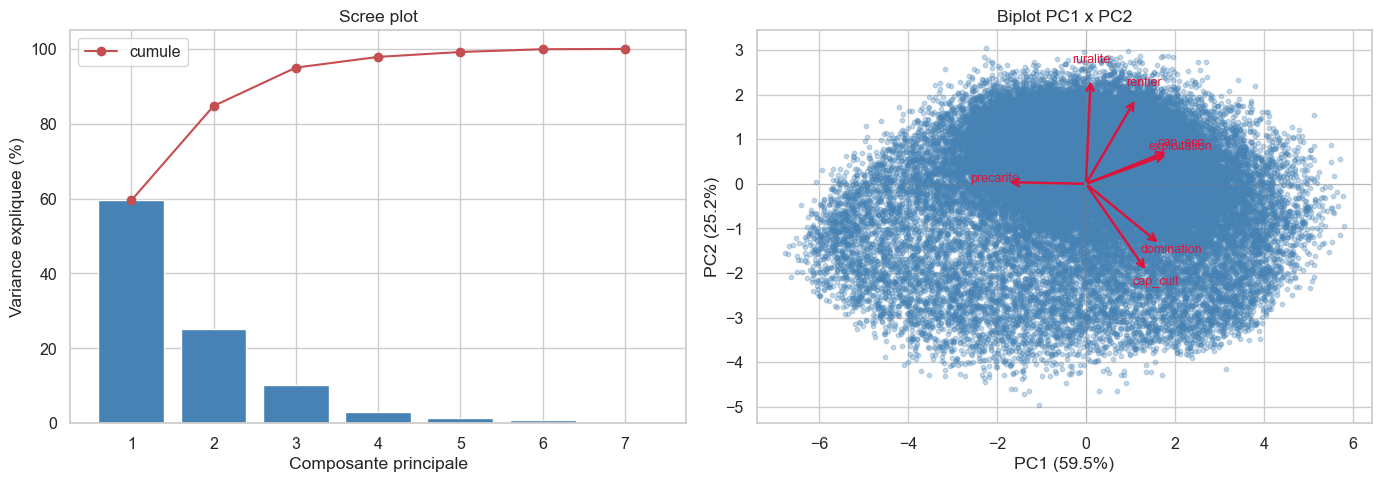

In [10]:
X = StandardScaler().fit_transform(df_clean[SCORES].dropna())
pca = PCA()
pca.fit(X)
ev = pca.explained_variance_ratio_
scores_pca = pca.transform(X)
loadings   = pca.components_[:2]

print('Variance expliquee par composante :')
for i, v in enumerate(ev):
    print(f'  PC{i+1}: {v*100:.1f}%  (cumule: {np.cumsum(ev)[i]*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(ev)+1), ev*100, color='steelblue', edgecolor='white')
axes[0].plot(range(1, len(ev)+1), np.cumsum(ev)*100, 'r-o', ms=6, label='cumule')
axes[0].set_xlabel('Composante principale')
axes[0].set_ylabel('Variance expliquee (%)')
axes[0].set_title('Scree plot')
axes[0].legend()
axes[0].set_xticks(range(1, len(ev)+1))

axes[1].scatter(scores_pca[:, 0], scores_pca[:, 1], s=10, alpha=0.3, color='steelblue')
scale = 4
for j, lbl in enumerate(SCORE_LABELS):
    axes[1].annotate('', xy=(loadings[0,j]*scale, loadings[1,j]*scale), xytext=(0,0),
                     arrowprops=dict(arrowstyle='->', color='crimson', lw=1.8))
    axes[1].text(loadings[0,j]*scale*1.15, loadings[1,j]*scale*1.15, lbl,
                 fontsize=9, color='crimson', ha='center')
axes[1].axhline(0, color='grey', lw=0.5, ls=':')
axes[1].axvline(0, color='grey', lw=0.5, ls=':')
axes[1].set_xlabel(f'PC1 ({ev[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
axes[1].set_title('Biplot PC1 x PC2')

plt.tight_layout()
plt.show()


## 8. Corrélations variables `pct_*` × scores composites

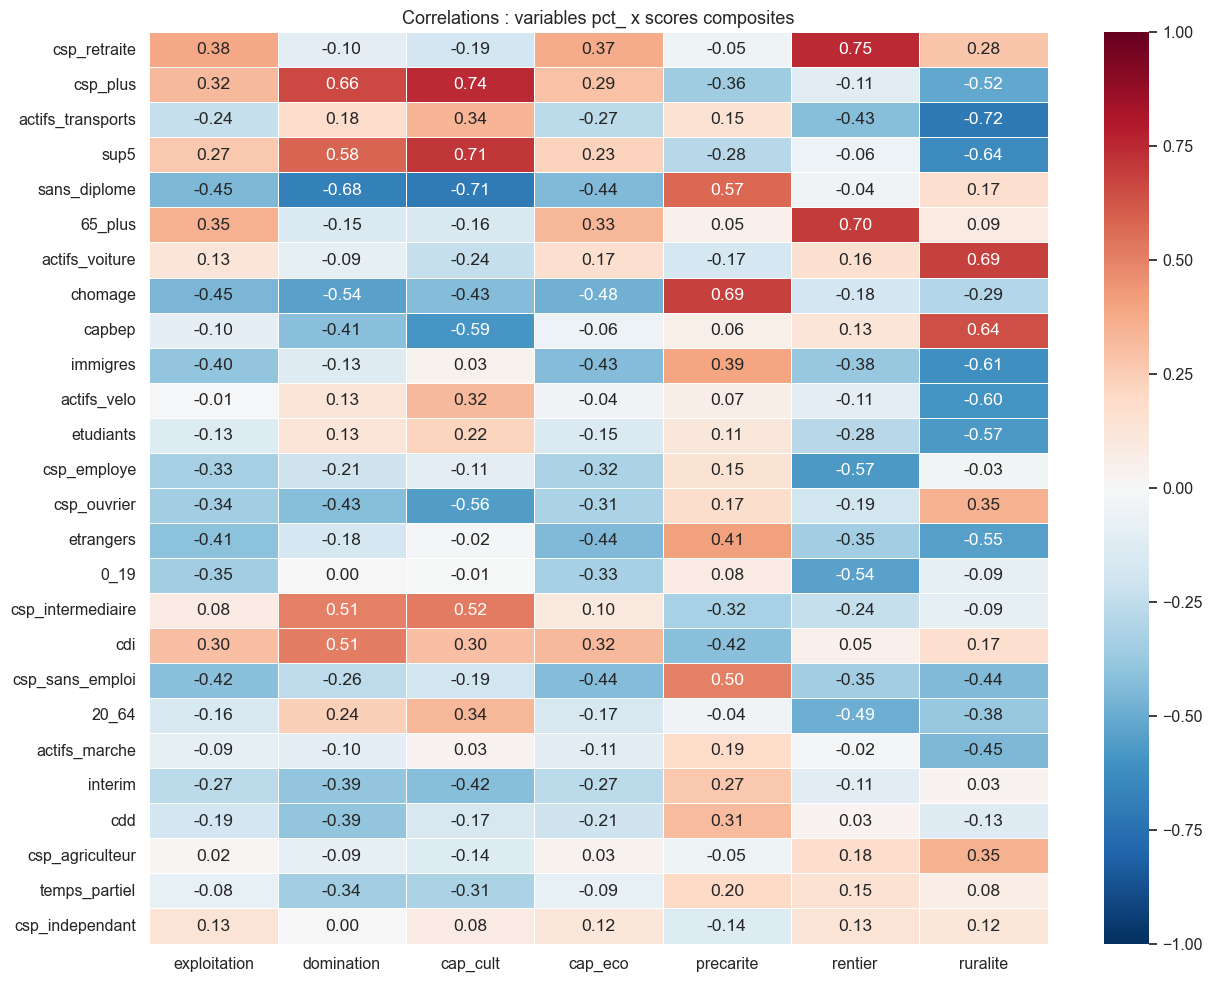

In [11]:
corr_pct = df_corr.corr().loc[PCT_ALL, SCORES]

# Trier par |r| max
order = corr_pct.abs().max(axis=1).sort_values(ascending=False).index
corr_sorted = corr_pct.loc[order]
pct_labels_sorted = [p.replace('pct_', '') for p in corr_sorted.index]

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr_sorted.values, annot=True, fmt='.2f',
            cmap='RdBu_r', vmin=-1, vmax=1, linewidths=0.4,
            xticklabels=SCORE_LABELS, yticklabels=pct_labels_sorted, ax=ax)
ax.set_title('Correlations : variables pct_ x scores composites', fontsize=13)
plt.tight_layout()
plt.show()


### Top 5 variables `pct_*` par score

In [12]:
for s in SCORES:
    col = corr_pct[s].dropna()
    top = col.abs().nlargest(5)
    print(f"\n{s.replace('score_','').upper()} :")
    for var in top.index:
        r = float(col.loc[var])
        print(f"  {'+' if r > 0 else '-'}{abs(r):.3f}  {var}")



EXPLOITATION :
  -0.455  pct_chomage
  -0.445  pct_sans_diplome
  -0.422  pct_csp_sans_emploi
  -0.408  pct_etrangers
  -0.396  pct_immigres

DOMINATION :
  -0.682  pct_sans_diplome
  +0.657  pct_csp_plus
  +0.582  pct_sup5
  -0.541  pct_chomage
  +0.508  pct_cdi

CAP_CULT :
  +0.742  pct_csp_plus
  +0.712  pct_sup5
  -0.706  pct_sans_diplome
  -0.592  pct_capbep
  -0.558  pct_csp_ouvrier

CAP_ECO :
  -0.484  pct_chomage
  -0.443  pct_sans_diplome
  -0.441  pct_etrangers
  -0.436  pct_csp_sans_emploi
  -0.432  pct_immigres

PRECARITE :
  +0.687  pct_chomage
  +0.574  pct_sans_diplome
  +0.504  pct_csp_sans_emploi
  -0.421  pct_cdi
  +0.408  pct_etrangers

RENTIER :
  +0.750  pct_csp_retraite
  +0.696  pct_65_plus
  -0.572  pct_csp_employe
  -0.542  pct_0_19
  -0.486  pct_20_64

RURALITE :
  -0.718  pct_actifs_transports
  +0.687  pct_actifs_voiture
  +0.643  pct_capbep
  -0.637  pct_sup5
  -0.610  pct_immigres


### Scatter plots — meilleures paires `pct_*` × score

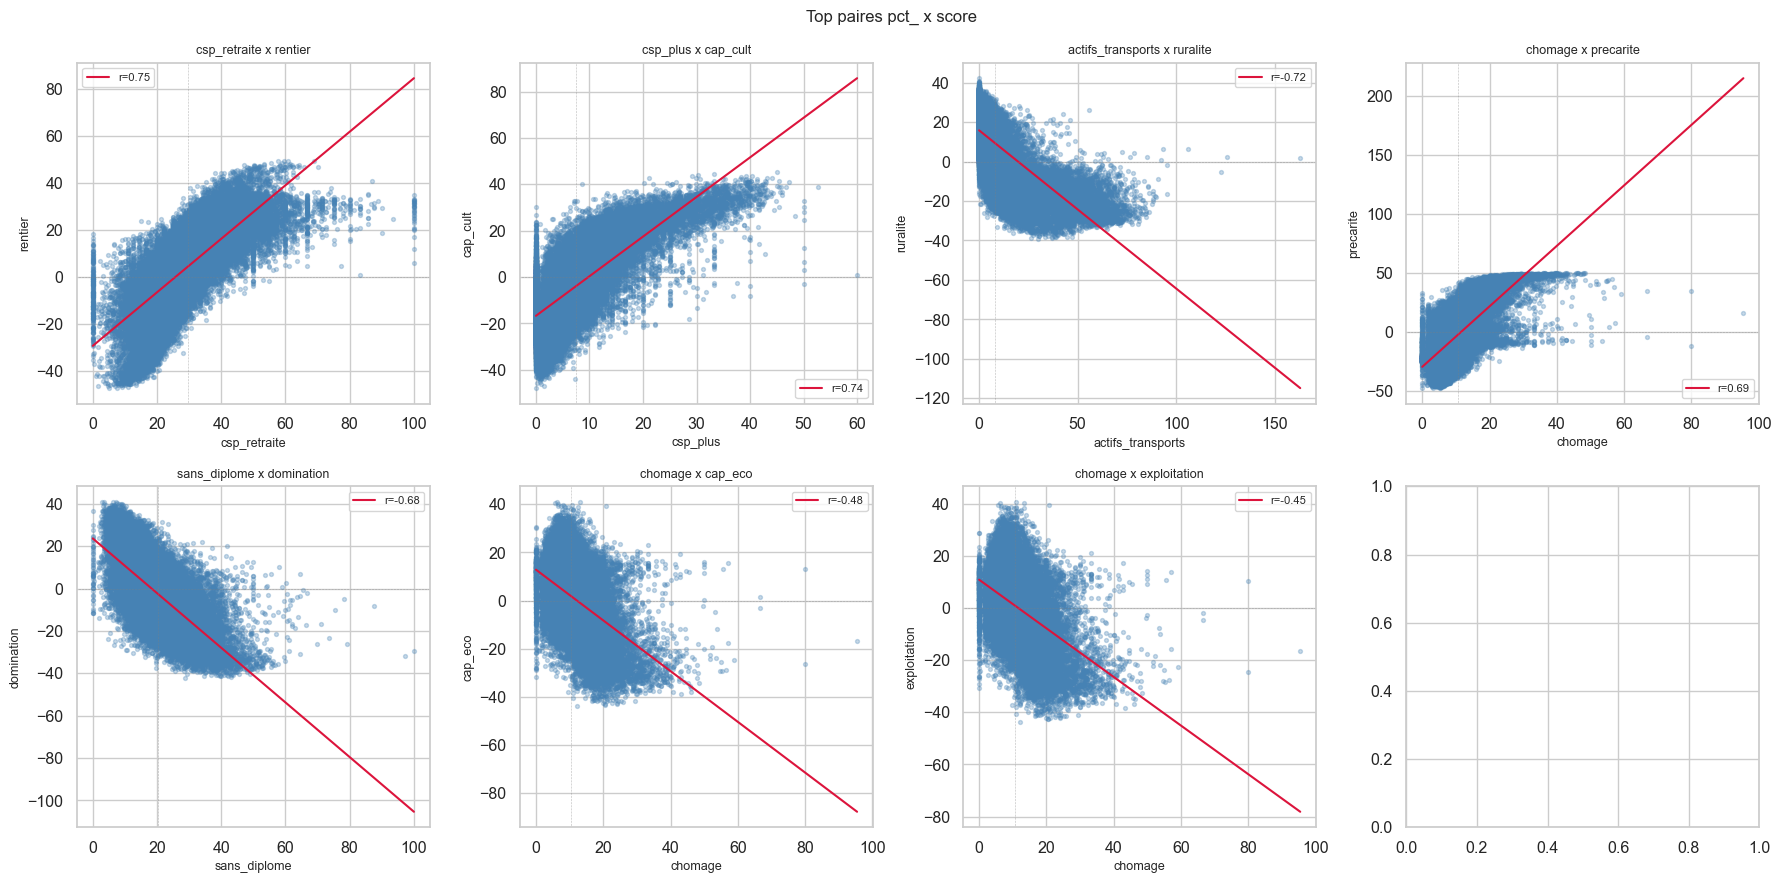

In [ ]:
pairs_pct = []
for s in SCORES:
    col = corr_pct[s].dropna()
    best = col.abs().idxmax()
    pairs_pct.append((best, s, float(col.loc[best])))
pairs_pct.sort(key=lambda x: abs(x[2]), reverse=True)
pairs_pct = pairs_pct[:8]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for ax, (pct_var, score, r) in zip(axes, pairs_pct):
    sub = df_corr[[pct_var, score]].dropna()
    xv, yv = sub[pct_var].values, sub[score].values
    ax.scatter(xv, yv, s=8, alpha=0.3, color='steelblue')
    m, b, *_ = spstats.linregress(xv, yv)
    xl = np.linspace(xv.min(), xv.max(), 200)
    ax.plot(xl, m*xl + b, color='crimson', lw=1.5, label=f'r={r:.2f}')
    ax.set_xlabel(pct_var.replace('pct_', ''), fontsize=9)
    ax.set_ylabel(score.replace('score_', ''), fontsize=9)
    ax.set_title(f"{pct_var.replace('pct_','')} x {score.replace('score_','')}", fontsize=9)
    ax.legend(fontsize=8)
    ax.axhline(0, color='grey', lw=0.4, ls=':')
    ax.axvline(xv.mean(), color='grey', lw=0.4, ls=':')
fig.suptitle('Top paires pct_ x score', fontsize=12)
plt.tight_layout()
plt.show()


## 9. Distributions des variables `pct_*` par groupe

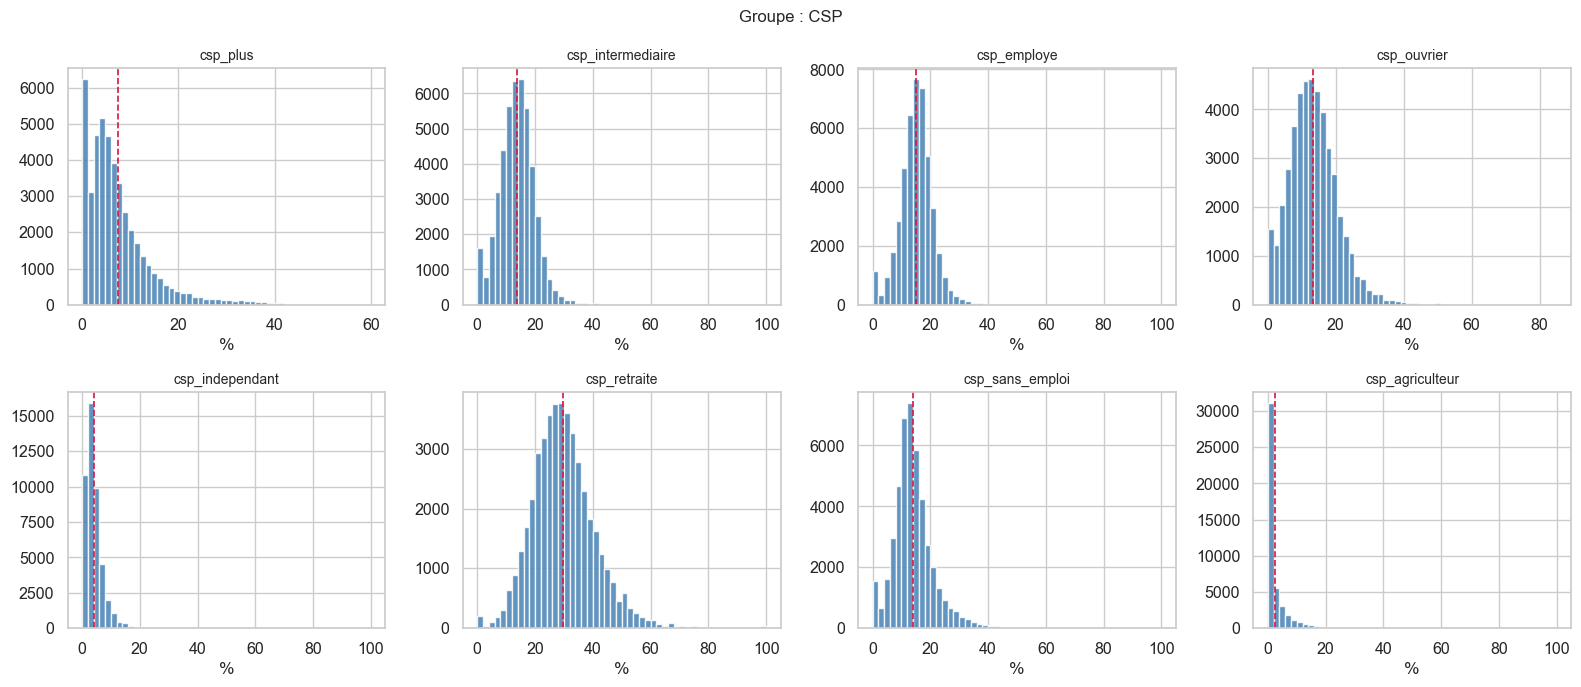

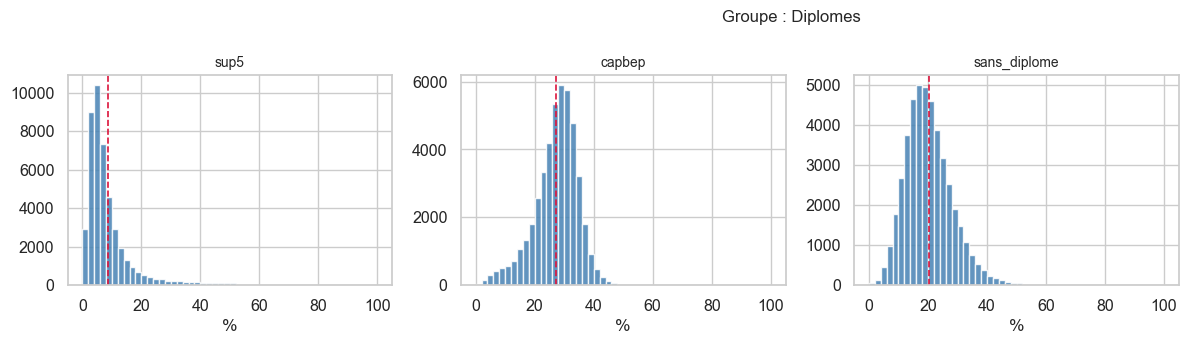

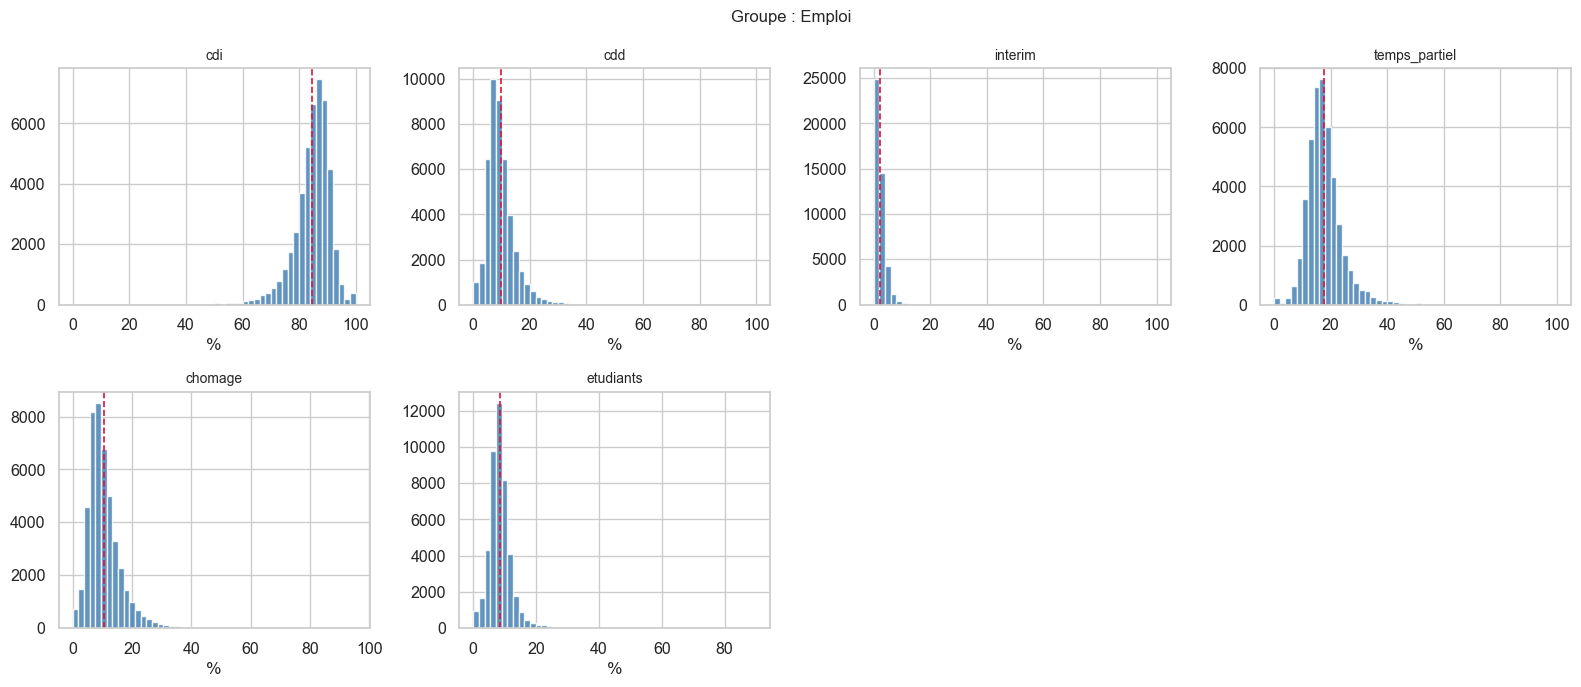

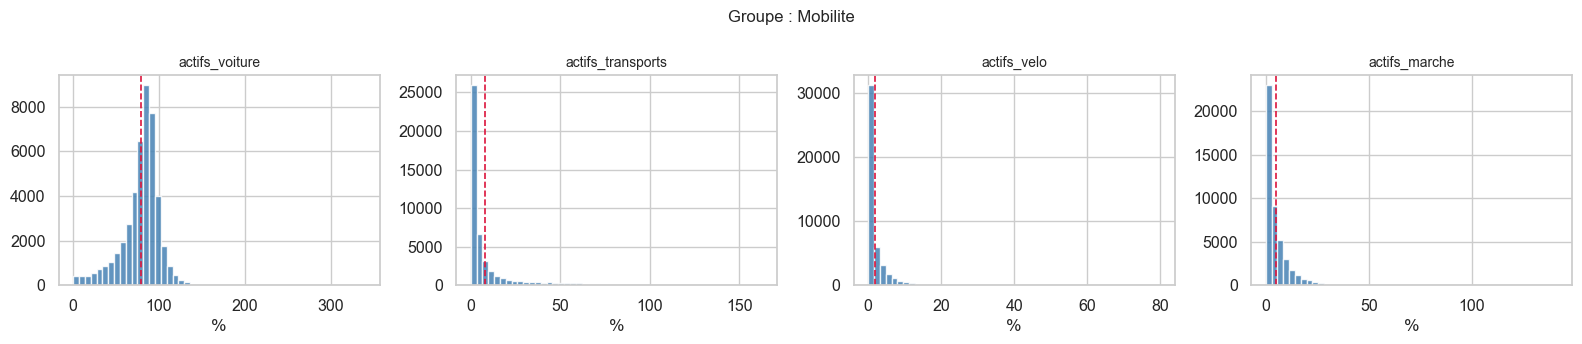

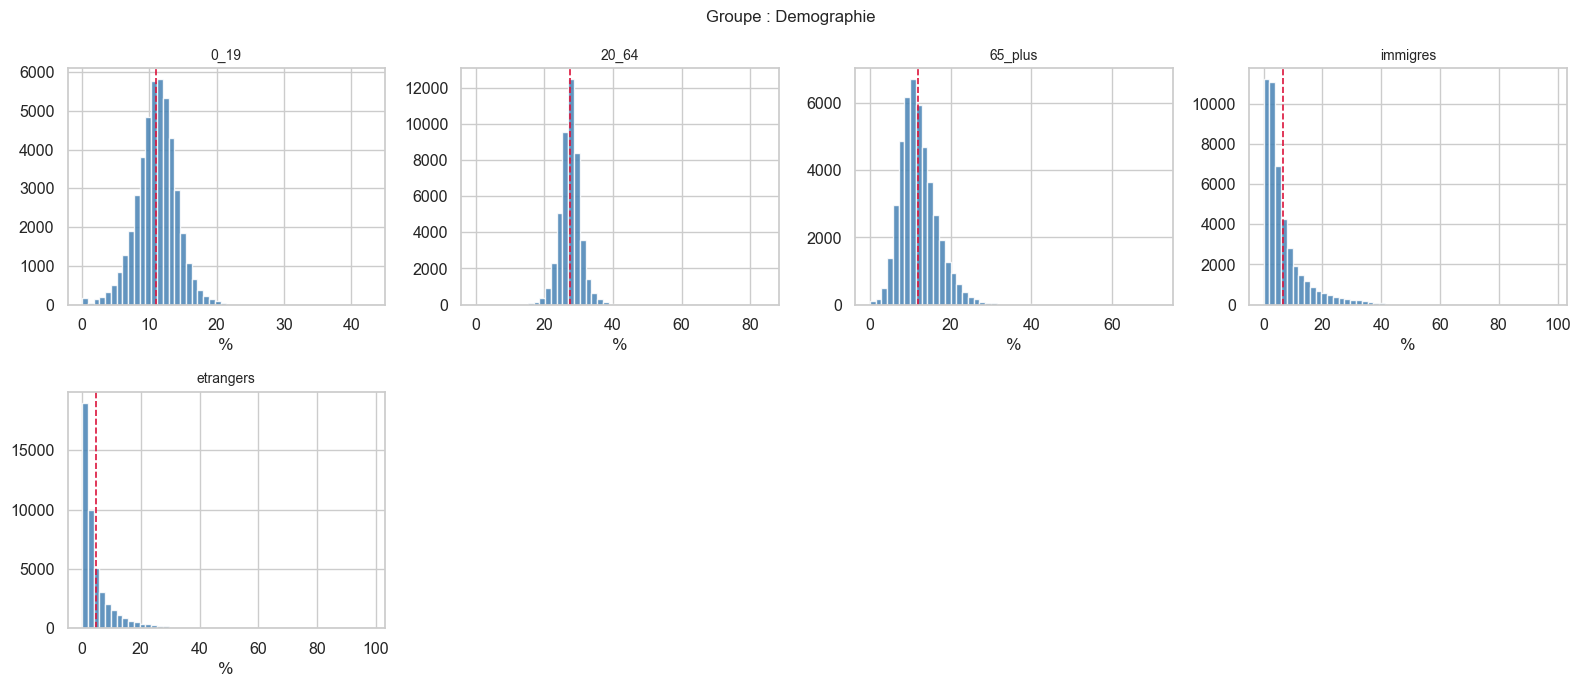

In [14]:
for grp_name, cols in PCT_GROUPS.items():
    ncols = 4
    nrows = -(-len(cols) // ncols)  # ceil division
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5 * nrows))
    axes = np.array(axes).flatten()
    for i, col in enumerate(cols):
        ax = axes[i]
        data = df_corr[col].dropna()
        ax.hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
        ax.axvline(data.mean(), color='crimson', lw=1.2, ls='--')
        ax.set_title(col.replace('pct_', ''), fontsize=10)
        ax.set_xlabel('%')
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(f'Groupe : {grp_name}', fontsize=12)
    plt.tight_layout()
    plt.show()
